In [ ]:
import heapq

# Graph represented as an adjacency list
graph = {
    'CS': [('Engineering', 10), ('Economics', 11), ('Urdu', 18)],
    'Engineering': [('CS', 10), ('Economics', 12), ('English', 12)],
    'Economics': [('CS', 11), ('Engineering', 12), ('English', 2), ('Urdu', 14)],
    'Urdu': [('CS', 18), ('Economics', 14), ('English', 16)],
    'English': [('Engineering', 12), ('Economics', 2), ('Urdu', 16)]
}

def prims_algorithm(start_node):
    visited = set()
    min_heap = []
    mst_edges = []
    total_cost = 0

    # Add all edges from the start node to the min heap
    visited.add(start_node)
    for neighbor, weight in graph[start_node]:
        heapq.heappush(min_heap, (weight, start_node, neighbor))

    while min_heap and len(visited) < len(graph):
        weight, from_node, to_node = heapq.heappop(min_heap)
        if to_node not in visited:
            visited.add(to_node)
            mst_edges.append((from_node, to_node, weight))
            total_cost += weight

            for neighbor, edge_weight in graph[to_node]:
                if neighbor not in visited:
                    heapq.heappush(min_heap, (edge_weight, to_node, neighbor))

    return mst_edges, total_cost

# Run the algorithm starting from 'Economics'
mst, cost = prims_algorithm('Economics')

print("Minimum Spanning Tree Edges (Prim's Algorithm):")
for edge in mst:
    print(f"{edge[0]} — {edge[1]} : {edge[2]}")

print(f"\nTotal Cost of MST: {cost}")


Minimum Spanning Tree Edges (Prim's Algorithm):
Economics — English : 2
Economics — CS : 11
CS — Engineering : 10
Economics — Urdu : 14

Total Cost of MST: 37


<ipython-input-2-74734c363dc6>:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


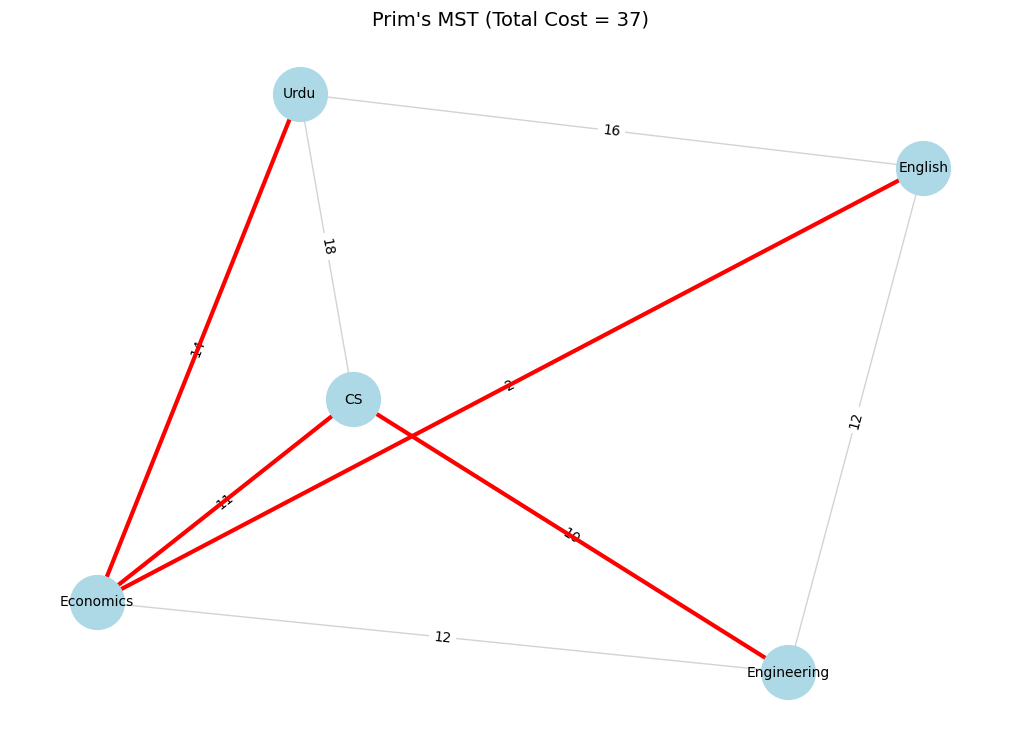

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import heapq

# Define the graph using adjacency list
graph = {
    'CS': [('Engineering', 10), ('Economics', 11), ('Urdu', 18)],
    'Engineering': [('CS', 10), ('Economics', 12), ('English', 12)],
    'Economics': [('CS', 11), ('Engineering', 12), ('English', 2), ('Urdu', 14)],
    'Urdu': [('CS', 18), ('Economics', 14), ('English', 16)],
    'English': [('Engineering', 12), ('Economics', 2), ('Urdu', 16)]
}

# Prim's Algorithm
def prims_algorithm(start_node):
    visited = set()
    min_heap = []
    mst_edges = []
    total_cost = 0

    visited.add(start_node)
    for neighbor, weight in graph[start_node]:
        heapq.heappush(min_heap, (weight, start_node, neighbor))

    while min_heap and len(visited) < len(graph):
        weight, from_node, to_node = heapq.heappop(min_heap)
        if to_node not in visited:
            visited.add(to_node)
            mst_edges.append((from_node, to_node, weight))
            total_cost += weight

            for neighbor, edge_weight in graph[to_node]:
                if neighbor not in visited:
                    heapq.heappush(min_heap, (edge_weight, to_node, neighbor))

    return mst_edges, total_cost

# Get MST from Prim’s Algorithm
mst_edges, total_cost = prims_algorithm('Economics')

# Create graph for visualization
G = nx.Graph()

# Add all nodes
for node in graph:
    G.add_node(node)

# Add all edges for full graph (to see context)
for node in graph:
    for neighbor, weight in graph[node]:
        if not G.has_edge(node, neighbor):
            G.add_edge(node, neighbor, weight=weight)

# Draw the full graph (light grey edges)
pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(10, 7))
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='lightgray', node_size=1500, font_size=10)
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): d['weight'] for u, v, d in G.edges(data=True)})

# Highlight MST edges in red
mst_edge_list = [(u, v) for u, v, w in mst_edges]
nx.draw_networkx_edges(G, pos, edgelist=mst_edge_list, edge_color='red', width=3)

plt.title(f"Prim's MST (Total Cost = {total_cost})", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# Kruskal's Algorithm for MST

# List of all edges (undirected graph)
edges = [
    ('CS', 'Engineering', 10),
    ('CS', 'Economics', 11),
    ('CS', 'Urdu', 18),
    ('Engineering', 'Economics', 12),
    ('Engineering', 'English', 12),
    ('Economics', 'English', 2),
    ('Economics', 'Urdu', 14),
    ('Urdu', 'English', 16)
]

# Disjoint Set (Union-Find) helper functions
parent = {}
rank = {}

def find(node):
    if parent[node] != node:
        parent[node] = find(parent[node])
    return parent[node]

def union(u, v):
    root_u = find(u)
    root_v = find(v)
    if root_u != root_v:
        if rank[root_u] < rank[root_v]:
            parent[root_u] = root_v
        elif rank[root_u] > rank[root_v]:
            parent[root_v] = root_u
        else:
            parent[root_v] = root_u
            rank[root_u] += 1
        return True
    return False

# Kruskal’s Algorithm
def kruskals_algorithm(edges):
    mst = []
    total_cost = 0

    # Initialize disjoint sets
    for u, v, _ in edges:
        if u not in parent:
            parent[u] = u
            rank[u] = 0
        if v not in parent:
            parent[v] = v
            rank[v] = 0

    # Sort edges by weight
    sorted_edges = sorted(edges, key=lambda x: x[2])

    for u, v, weight in sorted_edges:
        if union(u, v):
            mst.append((u, v, weight))
            total_cost += weight

    return mst, total_cost

# Run the algorithm
mst_edges, cost = kruskals_algorithm(edges)

# Output the result
print("Minimum Spanning Tree Edges (Kruskal's Algorithm):")
for u, v, w in mst_edges:
    print(f"{u} — {v} : {w}")

print(f"\nTotal Cost of MST: {cost}")


Minimum Spanning Tree Edges (Kruskal's Algorithm):
Economics — English : 2
CS — Engineering : 10
CS — Economics : 11
Economics — Urdu : 14

Total Cost of MST: 37


<ipython-input-4-a0c2f3a00ccf>:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


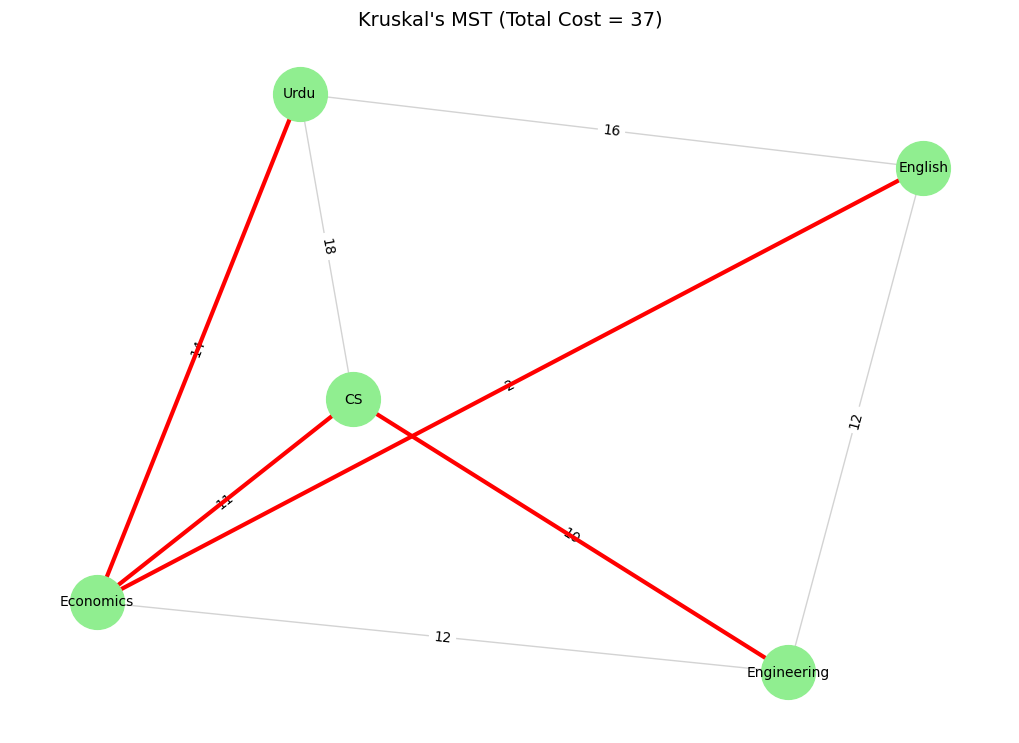

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Edges of the graph (node1, node2, weight)
edges = [
    ('CS', 'Engineering', 10),
    ('CS', 'Economics', 11),
    ('CS', 'Urdu', 18),
    ('Engineering', 'Economics', 12),
    ('Engineering', 'English', 12),
    ('Economics', 'English', 2),
    ('Economics', 'Urdu', 14),
    ('Urdu', 'English', 16)
]

# Disjoint set functions for Union-Find
parent = {}
rank = {}

def find(node):
    if parent[node] != node:
        parent[node] = find(parent[node])
    return parent[node]

def union(u, v):
    root_u = find(u)
    root_v = find(v)
    if root_u != root_v:
        if rank[root_u] < rank[root_v]:
            parent[root_u] = root_v
        elif rank[root_u] > rank[root_v]:
            parent[root_v] = root_u
        else:
            parent[root_v] = root_u
            rank[root_u] += 1
        return True
    return False

def kruskals_algorithm(edges):
    mst = []
    total_cost = 0

    # Initialize disjoint sets
    for u, v, _ in edges:
        if u not in parent:
            parent[u] = u
            rank[u] = 0
        if v not in parent:
            parent[v] = v
            rank[v] = 0

    # Sort edges by weight
    sorted_edges = sorted(edges, key=lambda x: x[2])

    for u, v, weight in sorted_edges:
        if union(u, v):
            mst.append((u, v, weight))
            total_cost += weight

    return mst, total_cost

# Get MST and total cost
mst_edges, total_cost = kruskals_algorithm(edges)

# Create a NetworkX graph
G = nx.Graph()
G.add_weighted_edges_from(edges)

# Positioning for consistent layout
pos = nx.spring_layout(G, seed=42)

# Draw the full graph in light gray
plt.figure(figsize=(10, 7))
nx.draw(G, pos, with_labels=True, node_color='lightgreen', edge_color='lightgray', node_size=1500, font_size=10)
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): d['weight'] for u, v, d in G.edges(data=True)})

# Highlight MST edges in red
mst_edge_list = [(u, v) for u, v, w in mst_edges]
nx.draw_networkx_edges(G, pos, edgelist=mst_edge_list, edge_color='red', width=3)

# Title
plt.title(f"Kruskal's MST (Total Cost = {total_cost})", fontsize=14)
plt.tight_layout()
plt.show()
